## FEMS Real-time Fire Danger for Southwest Montana Zone FDOP
### Written by: W. Matt Jolly
### Version: 0.4 alpha  (Workings graphs and all hourly->daily->SIG summaries)
### Date:  12 May 2026
##### Modified from: FEMS Technical Handout

In [1]:
import requests, json, bisect
import numpy as np
from gql import gql, Client
from gql.transport.requests import RequestsHTTPTransport
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import geopandas as gpd
import datetime as datetime
import Constants
import contextily as cx
from scipy import stats
from FEMSHelpers import *

In [2]:
# Colors for plotting from Red Yel Blue Colorbrewer palette
col1 = '#d53e4f'  # Red
col2 = '#fc8d59'
col3 = '#fee08b'
col4 = '#ffffbf'  # Yellow
col5 = '#e6f598'
col6 = '#99d594'
col7 = '#3288bd'  # Blue

In [3]:
url_fuelmodel = 'https://fems.fs2c.usda.gov/fuelmodel/apis/graphql' 
url_climatology = 'https://fems.fs2c.usda.gov/api/climatology/graphql' 

In [4]:
#https://github.com/graphql-python/gql

In [5]:
#!gql-cli https://fems.fs2c.usda.gov/fuelmodel/apis/graphql --print-schema --schema-download input_value_deprecation:true > fuelmodel_gql.graphql
#!gql-cli https://fems.fs2c.usda.gov/api/climatology/graphql --print-schema --schema-download input_value_deprecation:true > climatology_gql.graphql

In [6]:
# Setup a synchronous transport to pass to the client
transport = RequestsHTTPTransport(url=url_climatology,headers={"X-API-Key": Constants.API_KEY})

# Create a GraphQL client
client = Client(transport=transport)

# Get the FEMS station list and format it as a GeoPandas DataFrame

In [7]:
gdfStations = MakeFEMSWXStationDataframe(client)

### Create a historical NFDRS data file list for each station in each FDRA (SIG)

In [8]:
myStations = gdfStations[gdfStations.StationID.isin([241508,241513,241507,241302,241206,241403,241206,242911,242910,242902,101019,242915,242912,242907,242905,242914])]
myStationsVoronoi = myStations.voronoi_polygons()

## Read in and filter the historical FEMS fire danger data for a group of stations

In [9]:
def BuildSingleNFDRSHist(singlefilenm,myFuelModel = "Y"):
    dfout = pd.read_csv(singlefilenm)
    dfout['DateTime'] = pd.to_datetime(dfout.observationTime)
    dfout = dfout.sort_values(by='DateTime')
    dfout = dfout[dfout.fuelModelType == myFuelModel]
    return dfout

## Define the historical data files for each FDRA

In [10]:
lolo_west_fdra_hist_file = 'Data/lwfdr_histfd_Y.csv'
lolo_east_fdra_hist_file = 'Data/lefdr_histfd_Y.csv'
cskt_east_fdra_hist_file = 'Data/cskte_histfd_Y.csv'
cskt_west_fdra_hist_file = 'Data/csktw_histfd_Y.csv'
brf_high_fdra_hist_file = 'Data/brh_histfd_Y.csv'
brf_low_fdra_hist_file = 'Data/brl_histfd_Y_Z.csv'

## Define the station lists for each FDRA

In [11]:
lefdr_sta_id = str("241507,241508,241513")
lwfdr_sta_id = str("241507,241302,241206")
csktefdr_sta_id = str("241403")
csktwfdr_sta_id = str("241403,241206")
bhfdr_sta_id = str("242911,242910,242902,101019")
blfdr_sta_id = str("242915,242912,242907,242905,242914")

## Build the historical data for each FDRA based on the selected fuel model

In [12]:
df_hist_nfdrs_lwfdra    =  BuildSingleNFDRSHist(lolo_west_fdra_hist_file, myFuelModel = "Y")
df_hist_nfdrs_lwfdra.reset_index(inplace=True)
df_hist_nfdrs_lefdra    =  BuildSingleNFDRSHist(lolo_east_fdra_hist_file, myFuelModel = "Y")
df_hist_nfdrs_lefdra.reset_index(inplace=True)
df_hist_nfdrs_csktefdra =  BuildSingleNFDRSHist(cskt_east_fdra_hist_file, myFuelModel = "Y")
df_hist_nfdrs_csktefdra.reset_index(inplace=True)
df_hist_nfdrs_csktwfdra =  BuildSingleNFDRSHist(cskt_west_fdra_hist_file, myFuelModel = "Y")
df_hist_nfdrs_csktwfdra.reset_index(inplace=True)
df_hist_nfdrs_blfdra    =  BuildSingleNFDRSHist(brf_low_fdra_hist_file, myFuelModel = "Z")
df_hist_nfdrs_blfdra.reset_index(inplace=True)
df_hist_nfdrs_bhfdra    =  BuildSingleNFDRSHist(brf_high_fdra_hist_file, myFuelModel = "Y")
df_hist_nfdrs_bhfdra.reset_index(inplace=True)

# Define all percentile thresholds for this Zone

In [13]:
# ERC percentiles in the SW Zone 
lefdra_erc_percs=[20,30,43,49]
lwfdra_erc_percs=[14,30,44,51]
csktefdra_erc_percs = [14,27,36,42]
csktwfdra_erc_percs = [18,30,41,48]
blfdra_erc_percs = [40,77,94,105]
bhfdra_erc_percs = [15,33,45,52]

# BI percentiles in the SW Zone 
lefdra_bi_percs=[13,27]
lwfdra_bi_percs=[14,28]
csktefdra_bi_percs = [25,33]
csktwfdra_bi_percs = [18,28]
blfdra_bi_percs = [71,82] #[50,90]
bhfdra_bi_percs = [20,40]

In [14]:
def FilterDates(df,myStartDate,myEndDate):
    return df[(df.DateTime >= myStartDate) &(df.DateTime <= myEndDate)]
    
# Look up percentile classes
def LookupClass(myVal,myBreakpoints):
    # bisect_left returns the insertion point to maintain order
    index = bisect.bisect_left(myBreakpoints, myVal)
    return index

# Create the Dispatch Response Level matrix
DRL_Matrix = np.array([
    ['L', 'L', 'M','H','H+'],
    ['L', 'L', 'M','M','H'],
    ['L', 'L', 'L','M','M']
    
])

# Lookup the combined DRL class
def LookupDRLClass(x, y, matrix):
    # Returns class at x (column) and y (row)
    # Using [row, col] format
    return matrix[y, x]


## Summarize the hourly data files up to daily max/mins as appropriate
def SummarizeDaily(df_hist):
    df_hist['DateTime'] = pd.to_datetime(df_hist['observationTime'])
    df_hist.set_index('DateTime',inplace=True)
    # Resample to daily max and mins
    df_hist_max = df_hist.groupby('stationName').resample("1D").max().reset_index(drop=True)
    df_hist_max['DateTime'] = pd.to_datetime(df_hist_max['observationTime'])
    df_hist_max.set_index('DateTime',inplace=True)
    
    df_hist_min = df_hist.groupby('stationName').resample("1D").min().reset_index(drop=True)
    df_hist_min['DateTime'] = pd.to_datetime(df_hist_min['observationTime'])
    df_hist_min.set_index('DateTime',inplace=True)
    
       
    df_out = pd.DataFrame() 
    df_out['DateTime'] = df_hist_min.resample("1D").observationTime.min()
    df_out['MC1DailyMin'] = df_hist_min.resample("1D").oneHR_TL_FuelMoisture.mean()
    df_out['MC10DailyMin'] = df_hist_min.resample("1D").tenHR_TL_FuelMoisture.mean()
    df_out['MC100DailyMin'] = df_hist_min.resample("1D").hundredHR_TL_FuelMoisture.mean()
    df_out['MC1000DailyMin'] = df_hist_min.resample("1D").thousandHR_TL_FuelMoisture.mean()
    df_out['MCHERBDailyMin'] = df_hist_min.resample("1D").herbaceousLFI_fuelMoisture.mean()
    df_out['MCWOODDailyMin'] = df_hist_min.resample("1D").woodyLFI_fuelMoisture.mean()
    
    df_out['ERCDailyMax'] = df_hist_max.resample("1D").energyReleaseComponent.mean()
    df_out['BIDailyMax'] = df_hist_max.resample("1D").burningIndex.mean()
    
    return df_out
    

# Summarize historical hourly data to daily 

In [15]:
# Summarize hourly to daily
df_hist_nfdrs_daily_lefdra = SummarizeDaily(df_hist_nfdrs_lefdra)
df_hist_nfdrs_daily_lwfdra = SummarizeDaily(df_hist_nfdrs_lwfdra)
df_hist_nfdrs_daily_csktefdra = SummarizeDaily(df_hist_nfdrs_csktefdra)
df_hist_nfdrs_daily_csktwfdra = SummarizeDaily(df_hist_nfdrs_csktwfdra)
df_hist_nfdrs_daily_blfdra = SummarizeDaily(df_hist_nfdrs_blfdra)
df_hist_nfdrs_daily_bhfdra = SummarizeDaily(df_hist_nfdrs_bhfdra)

# Filter for the FDOP analysis period
df_hist_nfdrs_daily_lefdra = FilterDates(df_hist_nfdrs_daily_lefdra,"2005-01-01","2025-12-31")
df_hist_nfdrs_daily_lwfdra = FilterDates(df_hist_nfdrs_daily_lwfdra,"2005-01-01","2025-12-31")
df_hist_nfdrs_daily_csktefdra = FilterDates(df_hist_nfdrs_daily_csktefdra,"2005-01-01","2025-12-31")
df_hist_nfdrs_daily_csktwfdra = FilterDates(df_hist_nfdrs_daily_csktwfdra,"2005-01-01","2025-12-31")
df_hist_nfdrs_daily_blfdra = FilterDates(df_hist_nfdrs_daily_blfdra,"2005-01-01","2025-12-31")
df_hist_nfdrs_daily_bhfdra = FilterDates(df_hist_nfdrs_daily_bhfdra,"2005-01-01","2025-12-31")

# Calculate the historical percentiles and SFDI and store the SFDI breakpoint tables

In [16]:
def CalcHistPercs(df):
    df['ERCPerc'] = df.ERCDailyMax.rank(pct=True)
    df['BIPerc'] = df.BIDailyMax.rank(pct=True)
    df['SFDIPerc'] = df['ERCPerc'] * df['BIPerc']
    sfdi_breaks = df['SFDIPerc'].quantile([0.6,0.8,0.9,0.97])
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    return df,sfdi_breaks

In [17]:
df_hist_nfdrs_daily_lefdra, lefdra_sfdi_breaks = CalcHistPercs(df_hist_nfdrs_daily_lefdra)
df_hist_nfdrs_daily_lwfdra, lwfdra_sfdi_breaks = CalcHistPercs(df_hist_nfdrs_daily_lwfdra)
df_hist_nfdrs_daily_csktefdra, csktefdra_sfdi_breaks = CalcHistPercs(df_hist_nfdrs_daily_csktefdra)
df_hist_nfdrs_daily_csktwfdra, csktwfdra_sfdi_breaks = CalcHistPercs(df_hist_nfdrs_daily_csktwfdra)
df_hist_nfdrs_daily_blfdra, blfdra_sfdi_breaks = CalcHistPercs(df_hist_nfdrs_daily_blfdra)
df_hist_nfdrs_daily_bhfdra, bhfdra_sfdi_breaks = CalcHistPercs(df_hist_nfdrs_daily_bhfdra)

In [18]:
sfdi_breaks = {'lefdra':lefdra_sfdi_breaks.values,'lwfdra':lwfdra_sfdi_breaks.values,'cskte':csktefdra_sfdi_breaks.values,'csktw':csktwfdra_sfdi_breaks.values,'blfdra':blfdra_sfdi_breaks.values,'bhfdra':bhfdra_sfdi_breaks.values}

In [19]:
# Provide a GraphQL query
query = gql(""" query NFDRSObs ($stationIds: String!,$FuelModels: String!,$StartDate: Date!,$EndDate:Date!) { 
nfdrsObs(startDateRange: $StartDate endDateRange: $EndDate, stationIds: $stationIds, fuelModels: $FuelModels, per_page: 1000000, page: 0 ) { 
data { station_name
  station_id
  wrcc_id
  latitude
  longitude
  elevation
  observation_time
  nfdr_date
  nfdr_time
  nfdr_type
  fuel_model
  fuel_model_version
  kbdi
  one_hr_tl_fuel_moisture
  ten_hr_tl_fuel_moisture
  hun_hr_tl_fuel_moisture
  thou_hr_tl_fuel_moisture
  ignition_component
  spread_component
  energy_release_component
  burning_index
  herbaceous_lfi_fuel_moisture
  woody_lfi_fuel_moisture
  gsi
  observation_type
}}} """ 
)



In [20]:
# Grab the real-time data for FEMS
def GetRTFEMSData(sta_id,FuelModel="Y"):
    currYear = datetime.now().year
    myStartDateTxt = f"{currYear}-01-01"
    myEndDateTxt = (datetime.now() + timedelta(days=7)).strftime("%Y-%m-%d")
    params = {"stationIds": sta_id,"FuelModels": FuelModel,"StartDate":myStartDateTxt,"EndDate":myEndDateTxt}
    result = client.execute_sync(query,variable_values=params)
    return(result)


In [21]:
# Create strings of yesterday, today and tomorrow dates for plotting and display

In [22]:
yesterdayStr = (datetime.now() + timedelta(days=-1)).strftime("%Y-%m-%d")
todayStr = (datetime.now() + timedelta(days=0)).strftime("%Y-%m-%d")
tomorrowStr = (datetime.now() + timedelta(days=1)).strftime("%Y-%m-%d")

# Grab the real-time and forecast weather data for each FDRA

In [23]:
df_lefdr = MakeFEMSNFDRSDataframe(GetRTFEMSData(lefdr_sta_id))
df_lwfdr = MakeFEMSNFDRSDataframe(GetRTFEMSData(lwfdr_sta_id))
df_csktefdr = MakeFEMSNFDRSDataframe(GetRTFEMSData(csktefdr_sta_id))
df_csktwfdr = MakeFEMSNFDRSDataframe(GetRTFEMSData(csktwfdr_sta_id))
df_blfdr = MakeFEMSNFDRSDataframe(GetRTFEMSData(blfdr_sta_id,FuelModel="Z"))
df_bhfdr = MakeFEMSNFDRSDataframe(GetRTFEMSData(bhfdr_sta_id))

## Resample the real-time to daily across all stations in the FDRA

In [24]:
def SummarizeDailyRT(df):
    
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df.set_index('DateTime',inplace=True)
    df_max = df[df.ObsType == "O"]
    df_max = df_max.groupby('StationID').resample("1D").max()
    df_o = df_max.droplevel('StationID').resample("1D")[['ERC','BI','MC1','MC10','MC100','MC1000','WOOD']].mean()
    df_o['ObsType'] = "O"
    
    df_max = df[df.ObsType == "F"]
    df_max = df_max.groupby('StationID').resample("1D").max()
    df_f = df_max.droplevel('StationID').resample("1D")[['ERC','BI','MC1','MC10','MC100','MC1000','WOOD']].mean()
    df_f['ObsType'] = "F"
    return pd.concat([df_o,df_f])
    

In [25]:
lefdr_daily_max = SummarizeDailyRT(df_lefdr) #.groupby(df_lefdr.DateTime.dt.date).max()
lwfdr_daily_max = SummarizeDailyRT(df_lwfdr)
csktefdr_daily_max = SummarizeDailyRT(df_csktefdr)
csktwfdr_daily_max = SummarizeDailyRT(df_csktwfdr)
blfdr_daily_max = SummarizeDailyRT(df_blfdr)
bhfdr_daily_max = SummarizeDailyRT(df_bhfdr)

In [26]:
# Create a list of the historical and real-time data frames. Process assumes that they are paired.
df_hists = ['df_hist_nfdrs_daily_lefdra','df_hist_nfdrs_daily_lwfdra','df_hist_nfdrs_daily_csktefdra','df_hist_nfdrs_daily_csktwfdra','df_hist_nfdrs_daily_blfdra','df_hist_nfdrs_daily_bhfdra']
df_rt = ['lefdr_daily_max','lwfdr_daily_max','csktefdr_daily_max','csktwfdr_daily_max','blfdr_daily_max','bhfdr_daily_max']

# Calculate the ERC, BI and SFDI percentiles
for index, value in enumerate(df_hists):
    globals()[df_rt[index]]['ERCDailyMaxPerc'] = globals()[df_rt[index]].ERC.apply(lambda x: stats.percentileofscore(globals()[df_hists[index]].ERCDailyMax,x))
    globals()[df_rt[index]]['BIDailyMaxPerc'] = globals()[df_rt[index]].BI.apply(lambda x: stats.percentileofscore(globals()[df_hists[index]].BIDailyMax,x))
    globals()[df_rt[index]]['SFDIDailyMaxPerc'] = globals()[df_rt[index]].ERCDailyMaxPerc/100 * globals()[df_rt[index]].BIDailyMaxPerc/100

In [27]:
# Assign Fuel Models for each of the FDRAs
lefdr_daily_max['FuelModel'] = "Y"
lwfdr_daily_max['FuelModel'] = "Y"
csktefdr_daily_max['FuelModel'] = "Y"
csktwfdr_daily_max['FuelModel'] = "Y"
blfdr_daily_max['FuelModel'] = "Z"
bhfdr_daily_max['FuelModel'] = "Y"

In [28]:
# Calcualte the SFDI class using the sfdi_breaks lookup table

In [29]:
lefdr_daily_max['SFDI'] = lefdr_daily_max.apply(lambda row: LookupClass(row['SFDIDailyMaxPerc'],sfdi_breaks['lefdra']), axis=1)
lwfdr_daily_max['SFDI'] = lwfdr_daily_max.apply(lambda row: LookupClass(row['SFDIDailyMaxPerc'],sfdi_breaks['lwfdra']), axis=1)
csktefdr_daily_max['SFDI'] = csktefdr_daily_max.apply(lambda row: LookupClass(row['SFDIDailyMaxPerc'],sfdi_breaks['cskte']), axis=1)
csktwfdr_daily_max['SFDI'] = csktwfdr_daily_max.apply(lambda row: LookupClass(row['SFDIDailyMaxPerc'],sfdi_breaks['csktw']), axis=1)
blfdr_daily_max['SFDI'] = blfdr_daily_max.apply(lambda row: LookupClass(row['SFDIDailyMaxPerc'],sfdi_breaks['blfdra']), axis=1)
bhfdr_daily_max['SFDI'] = bhfdr_daily_max.apply(lambda row: LookupClass(row['SFDIDailyMaxPerc'],sfdi_breaks['bhfdra']), axis=1)

In [30]:
# Calculate the BI class from BI and the BI perc table
lefdr_daily_max['BIClass'] = lefdr_daily_max.apply(lambda row: LookupClass(row['BI'],lefdra_bi_percs), axis=1)
lwfdr_daily_max['BIClass'] = lwfdr_daily_max.apply(lambda row: LookupClass(row['BI'],lwfdra_bi_percs), axis=1)
csktefdr_daily_max['BIClass'] = csktefdr_daily_max.apply(lambda row: LookupClass(row['BI'],csktefdra_bi_percs), axis=1)
csktwfdr_daily_max['BIClass'] =csktwfdr_daily_max.apply(lambda row: LookupClass(row['BI'],csktwfdra_bi_percs), axis=1)
blfdr_daily_max['BIClass'] = blfdr_daily_max .apply(lambda row: LookupClass(row['BI'],blfdra_bi_percs), axis=1)
bhfdr_daily_max ['BIClass'] = bhfdr_daily_max .apply(lambda row: LookupClass(row['BI'],bhfdra_bi_percs), axis=1)

# Calculate the ERC class from ERC and the ERC perc table
lefdr_daily_max['ERCClass'] = lefdr_daily_max.apply(lambda row: LookupClass(row['ERC'],lefdra_bi_percs), axis=1)
lwfdr_daily_max['ERCClass'] = lwfdr_daily_max.apply(lambda row: LookupClass(row['ERC'],lwfdra_bi_percs), axis=1)
csktefdr_daily_max['ERCClass'] = csktefdr_daily_max.apply(lambda row: LookupClass(row['ERC'],csktefdra_bi_percs), axis=1)
csktwfdr_daily_max['ERCClass'] =csktwfdr_daily_max.apply(lambda row: LookupClass(row['ERC'],csktwfdra_bi_percs), axis=1)
blfdr_daily_max['ERCClass'] = blfdr_daily_max .apply(lambda row: LookupClass(row['ERC'],blfdra_bi_percs), axis=1)
bhfdr_daily_max ['ERCClass'] = bhfdr_daily_max .apply(lambda row: LookupClass(row['ERC'],bhfdra_bi_percs), axis=1)

# Calculate the Dispatch Reponse Level from the BI and ERC classes
lefdr_daily_max['DRLClass'] = lefdr_daily_max.apply(lambda row: LookupDRLClass(int(row['ERCClass']),int(row['BIClass']),DRL_Matrix), axis=1)
lwfdr_daily_max['DRLClass'] = lwfdr_daily_max.apply(lambda row: LookupDRLClass(int(row['ERCClass']),int(row['BIClass']),DRL_Matrix), axis=1)
csktefdr_daily_max['DRLClass'] = csktefdr_daily_max.apply(lambda row: LookupDRLClass(int(row['ERCClass']),int(row['BIClass']),DRL_Matrix), axis=1)
csktwfdr_daily_max['DRLClass'] = csktwfdr_daily_max.apply(lambda row: LookupDRLClass(int(row['ERCClass']),int(row['BIClass']),DRL_Matrix), axis=1)
blfdr_daily_max['DRLClass'] = blfdr_daily_max.apply(lambda row: LookupDRLClass(int(row['ERCClass']),int(row['BIClass']),DRL_Matrix), axis=1)
bhfdr_daily_max['DRLClass'] = bhfdr_daily_max.apply(lambda row: LookupDRLClass(int(row['ERCClass']),int(row['BIClass']),DRL_Matrix), axis=1)

In [31]:
lefdr_daily_max.reset_index(inplace=True)
lwfdr_daily_max.reset_index(inplace=True)
csktefdr_daily_max.reset_index(inplace=True)
csktwfdr_daily_max.reset_index(inplace=True)
blfdr_daily_max.reset_index(inplace=True)
bhfdr_daily_max.reset_index(inplace=True)

In [32]:
lefdr_daily_max['FDRA'] = "Lolo East"
lwfdr_daily_max['FDRA'] = "Lolo West"
csktwfdr_daily_max['FDRA'] = "CSKT West"
csktefdr_daily_max['FDRA'] = "CSKT East"
bhfdr_daily_max['FDRA'] = "Bitterroot High"
blfdr_daily_max['FDRA'] = "Bitterroot Low"

In [33]:
daily_max = pd.concat([lefdr_daily_max,lwfdr_daily_max,csktwfdr_daily_max,csktefdr_daily_max,blfdr_daily_max,bhfdr_daily_max])

In [34]:
daily_max.reset_index(inplace=True)

In [35]:
daily_max['DateTime'] = pd.to_datetime(daily_max['DateTime'])
daily_max = daily_max[daily_max.DateTime >= yesterdayStr]
daily_max['DateTimeStr'] = daily_max['DateTime'].dt.strftime("%Y-%b-%d")

In [36]:
def SFDIClassToText(val):
    if val == 0:
        return "Low"
    elif val == 1:
        return "Mod"
    elif val == 2:
        return "High"
    elif val == 3:
        return "Very High"
    elif val == 4:
        return "Severe"
    else:
        return "Unknown"

def BIClassToText(val):
    if val == 0:
        return "Low"
    elif val == 1:
        return "Mod"
    elif val == 2:
        return "High"
    else:
        return "Unknown"

def ERCClassToText(val):
    if val == 0:
        return "Low"
    elif val == 1:
        return "Mod"
    elif val == 2:
        return "High"
    elif val == 3:
        return "Very High"
    elif val == 4:
        return "Extreme"
    else:
        return "Unknown"

In [37]:
daily_max[daily_max.DateTime.dt.strftime("%Y-%m-%d") == tomorrowStr]

,index,DateTime,ERC,BI,MC1,MC10,MC100,MC1000,WOOD,ObsType,ERCDailyMaxPerc,BIDailyMaxPerc,SFDIDailyMaxPerc,FuelModel,SFDI,BIClass,ERCClass,DRLClass,FDRA,DateTimeStr
134,134,2026-05-13 00:00:00+00:00,39.896667,23.726667,21.006667,16.603333,12.340000,14.980000,69.716667,F,84.143956,76.763594,0.645919,Y,2,1,2,M,Lolo East,2026-May-13
275,134,2026-05-13 00:00:00+00:00,40.036667,23.113333,15.373333,12.346667,12.306667,14.713333,74.320000,F,85.643500,78.536967,0.672618,Y,2,1,2,M,Lolo West,2026-May-13
416,134,2026-05-13 00:00:00+00:00,40.565000,23.940000,13.390000,11.210000,11.865000,14.520000,93.390000,F,87.325597,75.198853,0.656678,Y,2,1,2,M,CSKT West,2026-May-13
557,134,2026-05-13 00:00:00+00:00,37.780000,24.060000,12.540000,10.730000,12.380000,15.370000,105.180000,F,90.096492,83.889686,0.755817,Y,2,0,2,M,CSKT East,2026-May-13
698,134,2026-05-13 00:00:00+00:00,94.730000,60.064000,30.754000,29.146000,10.928000,14.642000,89.778000,F,90.324684,78.184900,0.706203,Z,2,0,2,M,Bitterroot Low,2026-May-13
838,133,2026-05-13 00:00:00+00:00,31.930000,23.432500,28.647500,26.877500,14.395000,17.855000,87.180000,F,75.381406,75.303169,0.567646,Y,1,1,1,L,Bitterroot High,2026-May-13


In [38]:
daily_max_today_table = daily_max[daily_max.DateTime.dt.strftime("%Y-%m-%d") == todayStr][['FDRA','ObsType','FuelModel','DateTimeStr','ERCDailyMaxPerc','BIDailyMaxPerc','SFDIDailyMaxPerc','SFDI','BIClass','ERCClass','DRLClass','ERC','BI']]
daily_max_today_table['BItext'] = daily_max_today_table.apply(lambda row: BIClassToText(row['BIClass']), axis=1)
daily_max_today_table['ERCtext'] = daily_max_today_table.apply(lambda row: ERCClassToText(row['ERCClass']), axis=1)
daily_max_today_table['SFDItext'] = daily_max_today_table.apply(lambda row: SFDIClassToText(row['SFDI']), axis=1)
daily_max_today_table = daily_max_today_table.drop(columns=['SFDIDailyMaxPerc','SFDI','BIClass','ERCClass'])[['FDRA','ObsType','FuelModel','DateTimeStr','ERC','ERCDailyMaxPerc','BI','BIDailyMaxPerc','ERCtext','BItext','DRLClass','SFDItext']].round(1)
daily_max_today_table = daily_max_today_table.sort_values(by='ObsType')
daily_max_today_table

daily_max_today_table.to_csv('Tables/fire_danger_table_today.csv')

In [39]:
daily_max_tomorrow_table = daily_max[daily_max.DateTime.dt.strftime("%Y-%m-%d") == tomorrowStr][['FDRA','ObsType','FuelModel','DateTimeStr','ERCDailyMaxPerc','BIDailyMaxPerc','SFDIDailyMaxPerc','SFDI','BIClass','ERCClass','DRLClass','ERC','BI']]
daily_max_tomorrow_table['BItext'] = daily_max_tomorrow_table.apply(lambda row: BIClassToText(row['BIClass']), axis=1)
daily_max_tomorrow_table['ERCtext'] = daily_max_tomorrow_table.apply(lambda row: ERCClassToText(row['ERCClass']), axis=1)
daily_max_tomorrow_table['SFDItext'] = daily_max_tomorrow_table.apply(lambda row: SFDIClassToText(row['SFDI']), axis=1)
daily_max_tomorrow_table=daily_max_tomorrow_table.drop(columns=['SFDIDailyMaxPerc','SFDI','BIClass','ERCClass'])[['FDRA','ObsType','FuelModel','DateTimeStr','ERC','ERCDailyMaxPerc','BI','BIDailyMaxPerc','ERCtext','BItext','DRLClass','SFDItext']].round(1)
daily_max_tomorrow_table
daily_max_tomorrow_table.to_csv('Data/fire_danger_table_tomorrow.csv')

In [40]:
pd.pivot_table(daily_max, 
                       values='ERCDailyMaxPerc', 
                       index='FDRA', 
                       columns='DateTimeStr', 
                       aggfunc='max', 
                       fill_value=0)

DateTimeStr,2026-May-11,2026-May-12,2026-May-13,2026-May-14,2026-May-15,2026-May-16,2026-May-17,2026-May-18,2026-May-19
FDRA,,,,,,,,,
Bitterroot High,68.053201,74.246968,75.381406,69.943930,71.287000,73.581953,75.524840,77.689399,78.263137
Bitterroot Low,83.922285,88.825140,90.324684,63.711044,67.296910,71.052288,73.269005,73.464598,75.055418
CSKT East,85.265354,88.668666,90.096492,90.266006,88.401356,89.490155,90.298605,91.615595,92.554440
CSKT West,83.413744,85.591342,87.325597,86.986569,84.704655,85.773895,85.943409,87.377755,88.473073
Lolo East,79.932195,82.279306,84.143956,80.597210,79.397575,80.597210,81.216586,83.009519,83.987482
Lolo West,82.435780,84.391707,85.643500,84.717695,82.448820,83.244230,83.309428,84.548181,85.630460


In [41]:
daily_max = daily_max.copy()
daily_max['DateTime'] = pd.to_datetime(daily_max['DateTime'])


In [42]:
def MakePlot(df, df_hist,sta_ids,title,var,year,date,percs=[],fuelModel="Y",oFile=""):
    
    df = df[(df.DateTime >= f'01-01-{year}') & (df.DateTime <= f'12-31-{year}')]

    # Grab the most recent "O" types
    RecentERCPerc = df[(df.ObsType == "O")].iloc[[-1]]['ERCDailyMaxPerc'].round(1).values
    RecentBIPerc = df[(df.ObsType == "O")].iloc[[-1]]['BIDailyMaxPerc'].round(1).values
    RecentERC = df[(df.ObsType == "O")].iloc[[-1]]['ERC'].round(1).values
    RecentBI = df[(df.ObsType == "O")].iloc[[-1]]['BI'].round(1).values
    
    f,ax = plt.subplots()
    currPerc = ""
    # Define Products and Product Labels for maps
    Flip = False
    if var == "ERC":
        mvar = "ERCDailyMax"
        label = f"Energy Release Component (ERC)\n(Fuel Model {fuelModel}"
        currPerc = RecentERCPerc
    elif var == "BI":
        mvar = "BIDailyMax"
        label = f"Burning Index (BI)\n(Fuel Model {fuelModel}"
        currPerc = RecentBIPerc
    elif var == "MC1000":
        mvar = "MC1000DailyMin"
        label = f"1000-hr Fuel Moisture (%)"
        Flip = True
    elif var == "MC100":
        mvar = "MC100DailyMin"
        label = f"100-hr Fuel Moisture (%)"
        Flip = True
        
    # Plot the climatology
    df_hist[45:].groupby(df_hist.DateTime.dt.dayofyear)[mvar].max().plot(color=col1,rot=45,ax=ax,label='Max',legend=True,linewidth=0.75)
    df_hist[45:].groupby(df_hist.DateTime.dt.dayofyear)[mvar].mean().plot(color='grey',rot=45,ax=ax,label='Avg',legend=True,linewidth=0.75)
    df_hist[45:].groupby(df_hist.DateTime.dt.dayofyear)[mvar].min().plot(color=col7,rot=45,ax=ax,label='Min',legend=True,linewidth=0.75)

    # Plot the current values
    
    if var == "ERC" or var == "BI":
        currentLabel = f"{var}: {df[(df.ObsType == "O")].iloc[[-1]][var].round(1).values[0]} ({currPerc[0]}%)"
    else:
        currentLabel = f"{year}"
    df[(df.ObsType == "O")].iloc[[-1]][var].to_frame(name='Current').reset_index().plot.scatter(x='index',y='Current',ax=ax,c=col2,label=f"Current {currentLabel}")
    df[df.ObsType=="O"].groupby(df.DateTime.dt.dayofyear)[var].mean().plot(color=col2,ax=ax,rot=45,label= f"{var} ({year})",legend=True,linewidth=2)
    df[df.ObsType=="F"].groupby(df.DateTime.dt.dayofyear)[var].mean().plot(color=col2,ax=ax,rot=45,label="Forecast",legend=True,linestyle=':',linewidth=2)
   
    
    # Set the axis and plot a grid
    ax.set_axisbelow(True)
    ax.grid(True)

    # Make the plot pretty and informative
    ax.set_title(f"{sta_ids}")
    ax.set_xlabel("Yearday Date")
    ax.set_xlim([1,365])
    ax.set_ylabel(label)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
    # Use DateFormatter to format the labels as abbreviated month names (%b)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    if not Flip:
        perclow = df_hist[mvar].quantile([0.90]).round(1).values[0]
        perclowlabel = "90th Percentile"
        perchigh = df_hist[mvar].quantile([0.97]).round(1).values[0]
        perchighlabel = "97th Percentile"
    else:
        perclow = df_hist[mvar].quantile([0.10]).round(1).values[0]
        perclowlabel = "10th Percentile"
        perchigh = df_hist[mvar].quantile([0.03]).round(1).values[0]
        perchighlabel = "3rd Percentile"
        
    #if len(percs) > 0:
    ax.axhline(perclow,color='black',linestyle='--',label=f'{perclowlabel} ({perclow})')
    ax.axhline(perchigh,color='black',linestyle='-.',label=f'{perchighlabel} ({perchigh})')        
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 
    f.suptitle(f'{title} ({date})')
    if oFile != "":
        plt.savefig(oFile,bbox_inches='tight') 




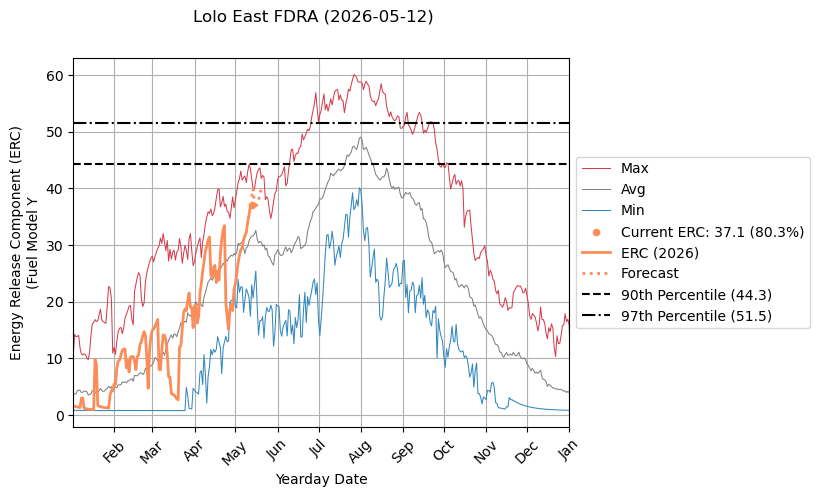

In [43]:
MakePlot(lefdr_daily_max,df_hist_nfdrs_daily_lefdra,"","Lolo East FDRA","ERC",2026,todayStr)    

In [44]:
units = []
# Lolo East and West
units.append({'rt_df':lefdr_daily_max,'hist_df':df_hist_nfdrs_daily_lefdra,'sta_list':lefdr_sta_id,'title':"Lolo East FDRA",'oFileBasePath': "Figures/LoloEastFDRA_",'Percs':{'ERC':lefdra_erc_percs},'FuelModel':"Y"})
units.append({'rt_df':lwfdr_daily_max,'hist_df':df_hist_nfdrs_daily_lwfdra,'sta_list':lwfdr_sta_id,'title':"Lolo West FDRA",'oFileBasePath': "Figures/LoloWestFDRA_",'Percs':{'ERC':lwfdra_erc_percs},'FuelModel':"Y"})

# CSKT East and West
units.append({'rt_df':csktefdr_daily_max,'hist_df':df_hist_nfdrs_daily_csktefdra,'sta_list':csktefdr_sta_id,'title':"CSKT East FDRA",'oFileBasePath': "Figures/LoloWestFDRA_",'Percs':{'ERC':csktefdra_erc_percs},'FuelModel':"Y"})
units.append({'rt_df':csktwfdr_daily_max,'hist_df':df_hist_nfdrs_daily_csktwfdra,'sta_list':csktwfdr_sta_id,'title':"CSKT West FDRA",'oFileBasePath': "Figures/LoloWestFDRA_",'Percs':{'ERC':csktwfdra_erc_percs},'FuelModel':"Y"})

# Bitterroot High and Low
units.append({'rt_df':blfdr_daily_max,'hist_df':df_hist_nfdrs_daily_blfdra,'sta_list':blfdr_sta_id,'title':"Bitterroot Low FDRA",'oFileBasePath': "Figures/BRFLowFDRA_",'Percs':{'ERC':blfdra_erc_percs},'FuelModel':"Z"})
units.append({'rt_df':bhfdr_daily_max,'hist_df':df_hist_nfdrs_daily_bhfdra,'sta_list':bhfdr_sta_id,'title':"Bitterroot High FDRA",'oFileBasePath': "Figures/BRFHighFDRA_",'Percs':{'ERC':bhfdra_erc_percs},'FuelModel':"Y"})

In [45]:
# Variables to plot
variables = ['ERC','BI','MC1000','MC100']

In [46]:
def IterateFigures(units, variables,year):
    for unit in units:
        for variable in variables:
            
            # Create the output plot file name
            oFile = f'{unit['oFileBasePath']}{variable}_current.png'
            if variable in unit['Percs']:
                percs = unit['Percs'][variable]
                MakePlot(unit['rt_df'],unit['hist_df'],unit['sta_list'],unit['title'],variable,year,todayStr,percs=percs,oFile=oFile)
            else:
                MakePlot(unit['rt_df'],unit['hist_df'],unit['sta_list'],unit['title'],variable,year,todayStr,oFile=oFile)
            

C:\Users\mjolly\AppData\Local\Temp\ipykernel_57204\550231717.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f,ax = plt.subplots()


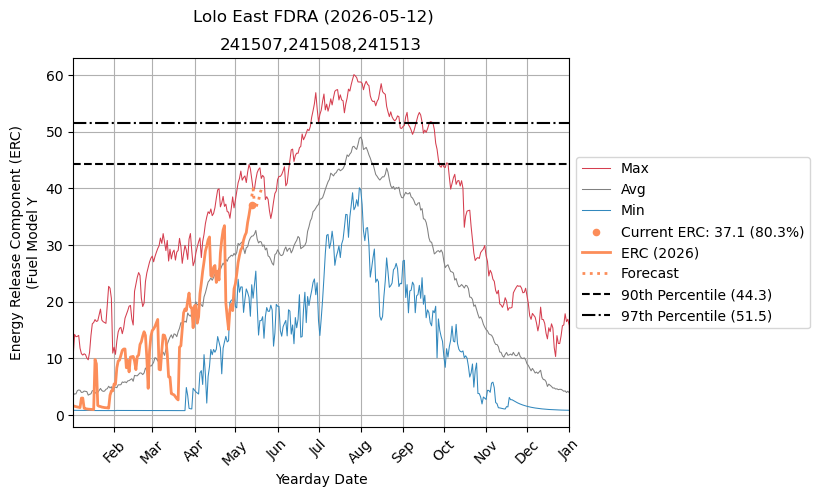

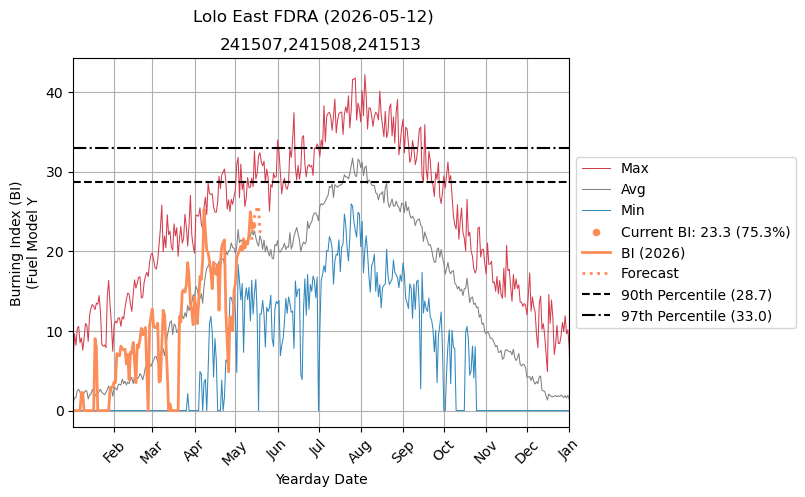

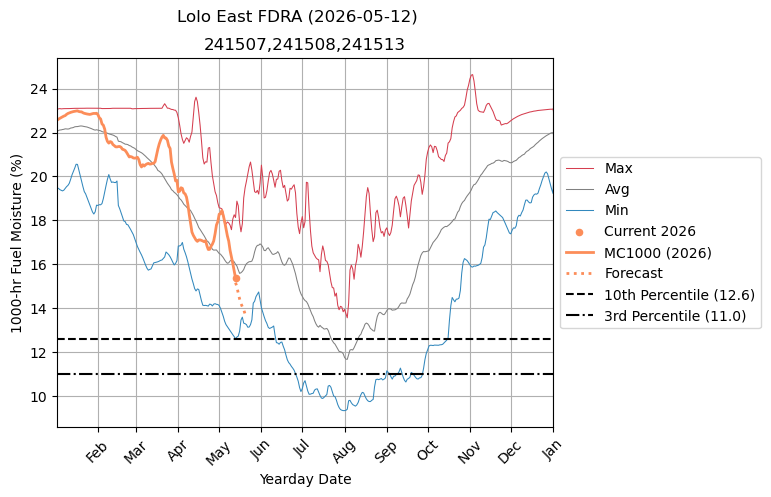

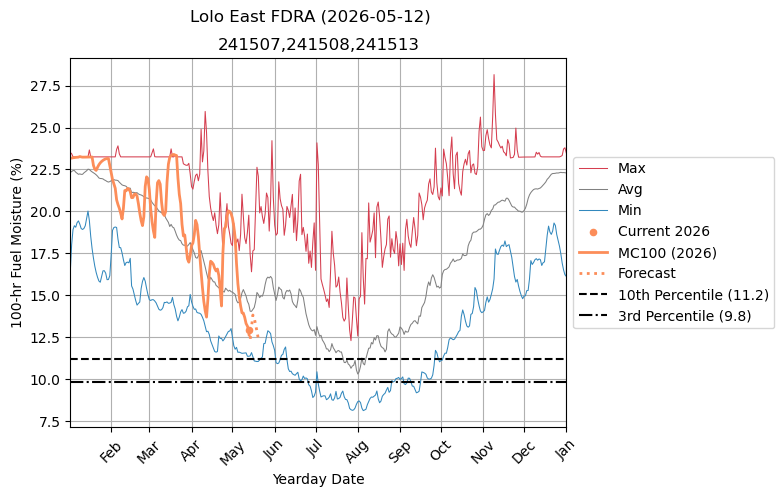

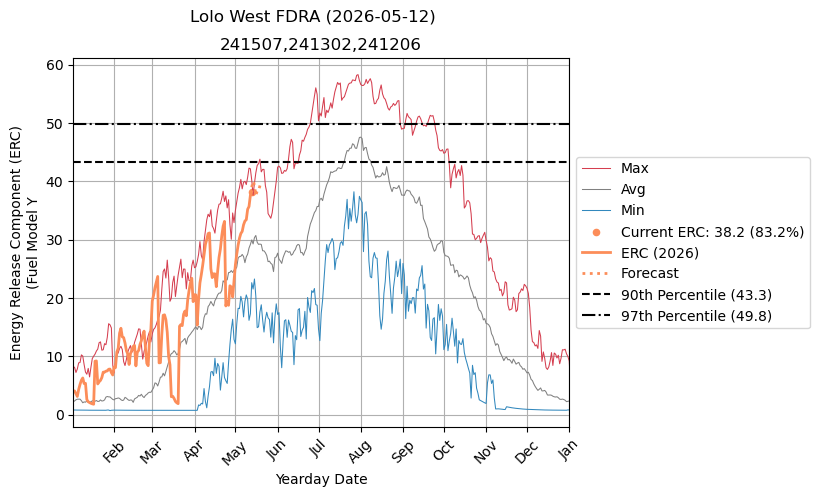

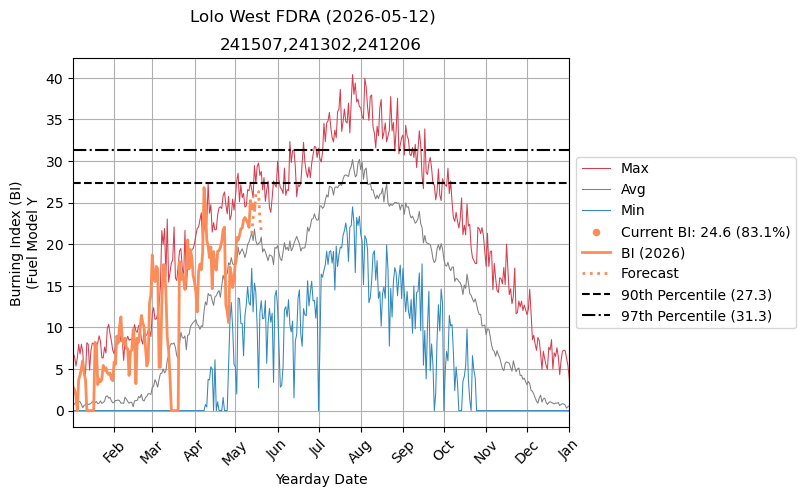

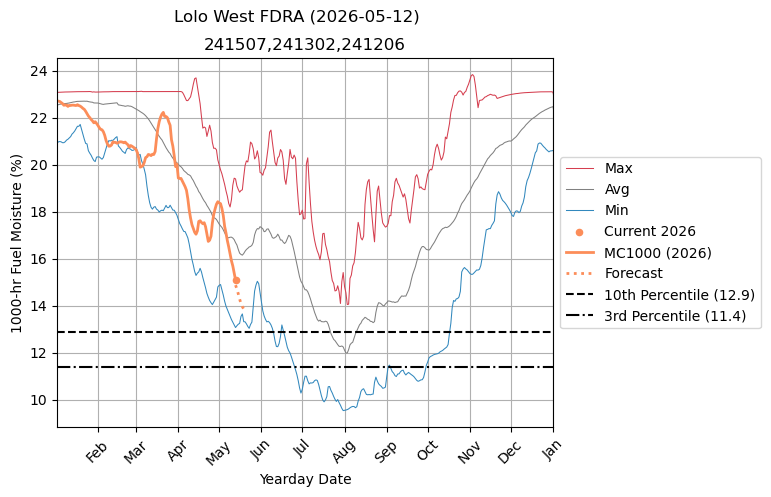

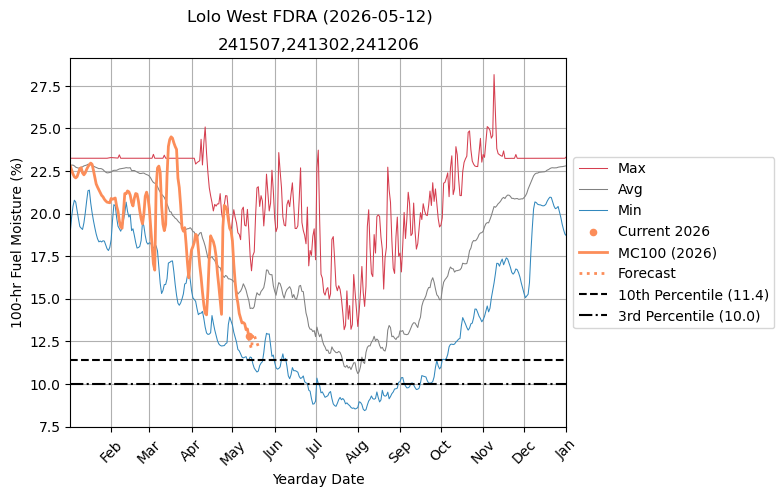

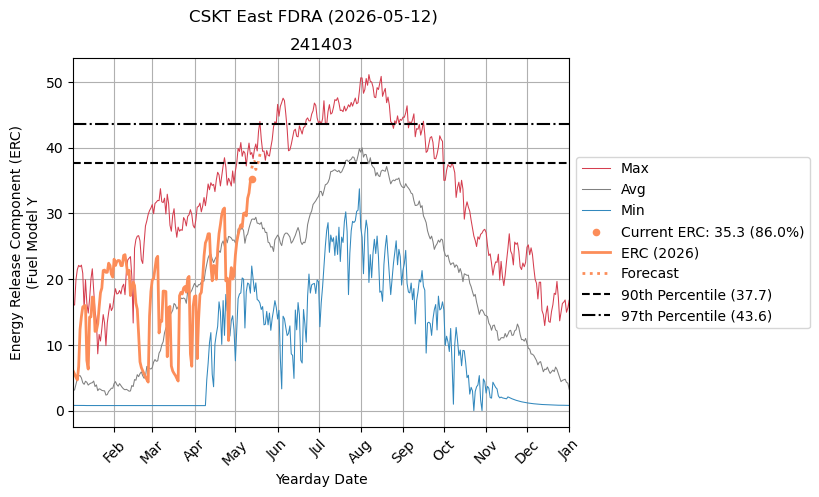

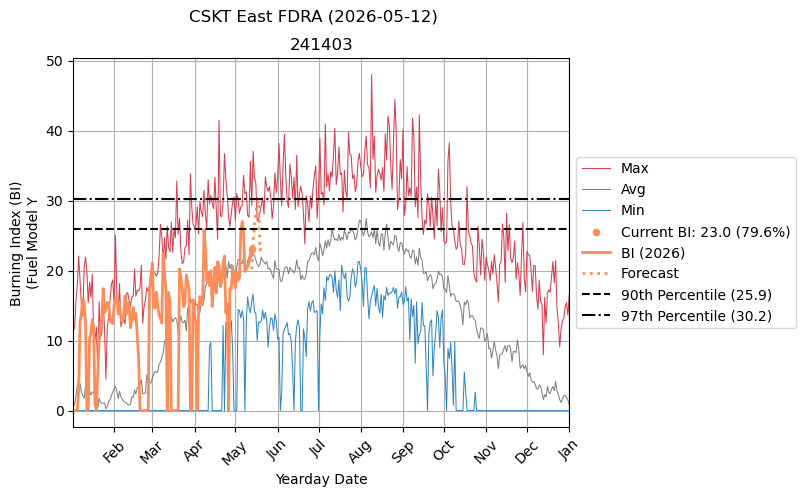

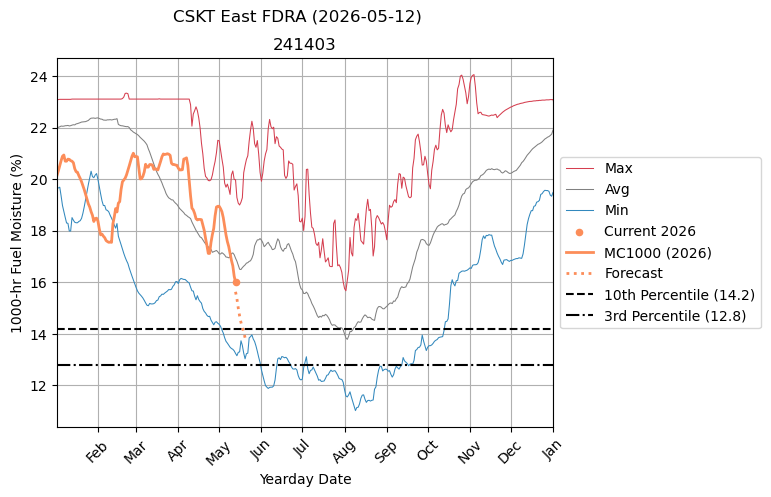

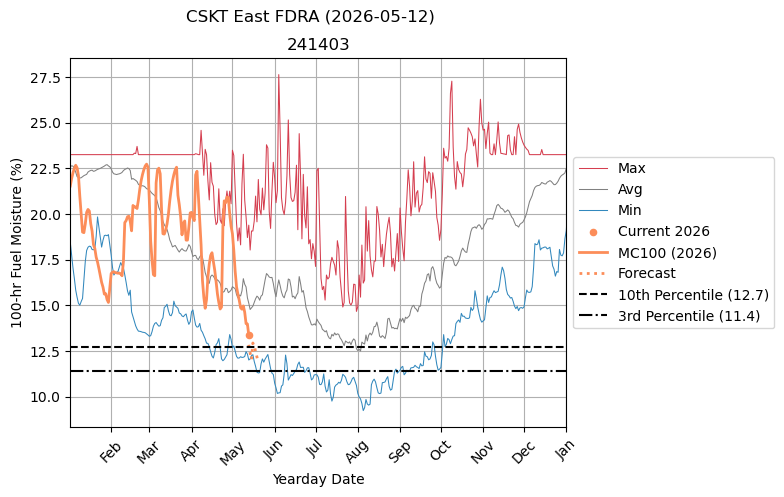

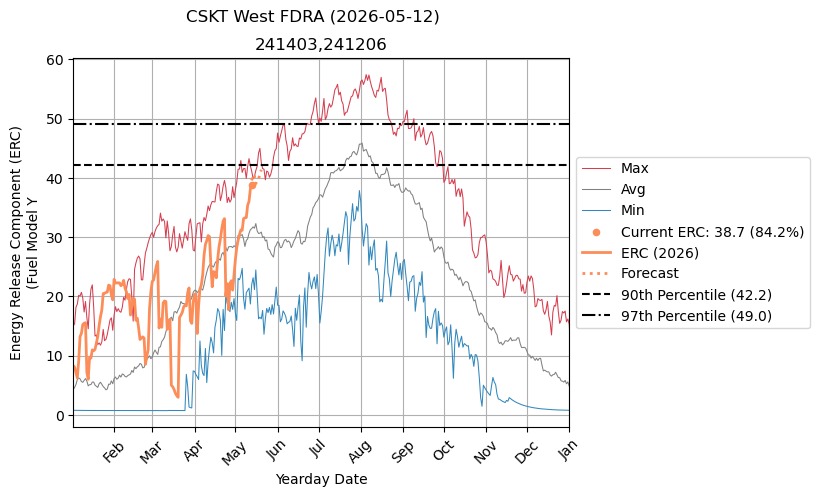

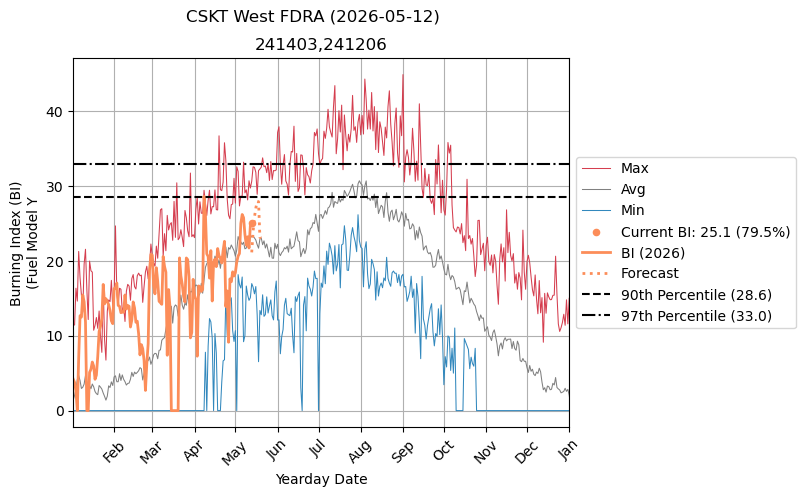

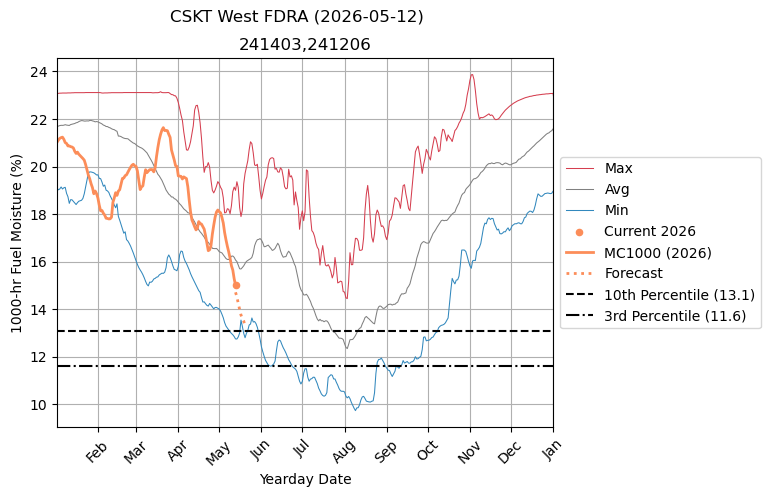

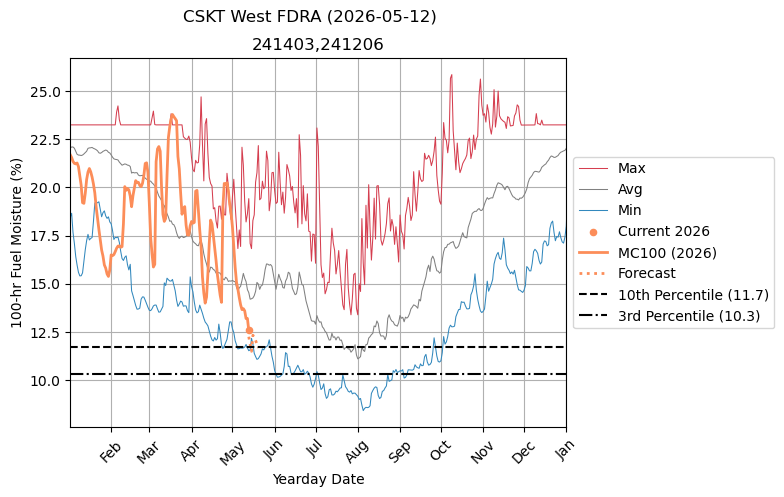

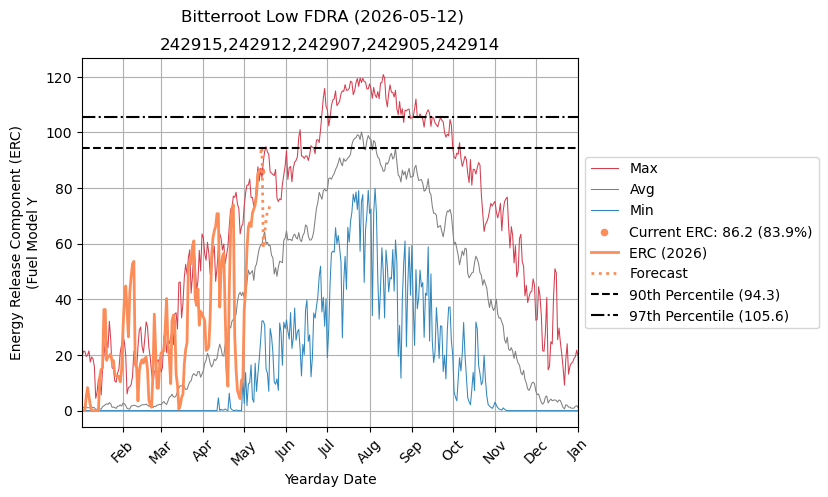

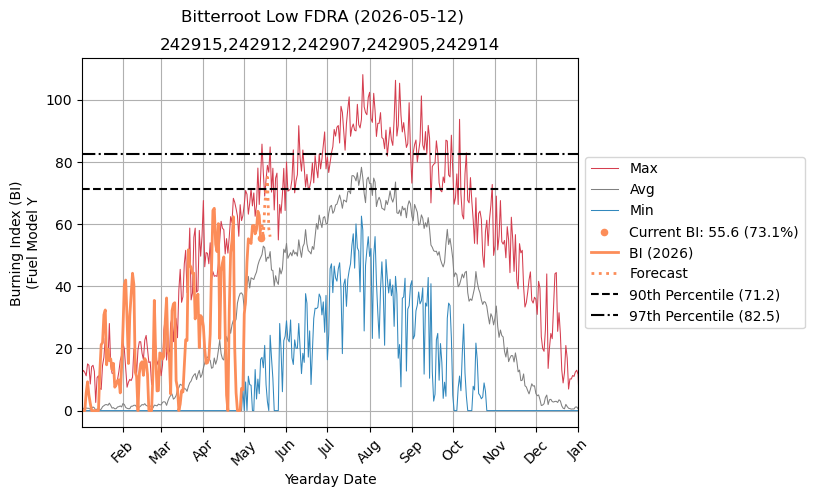

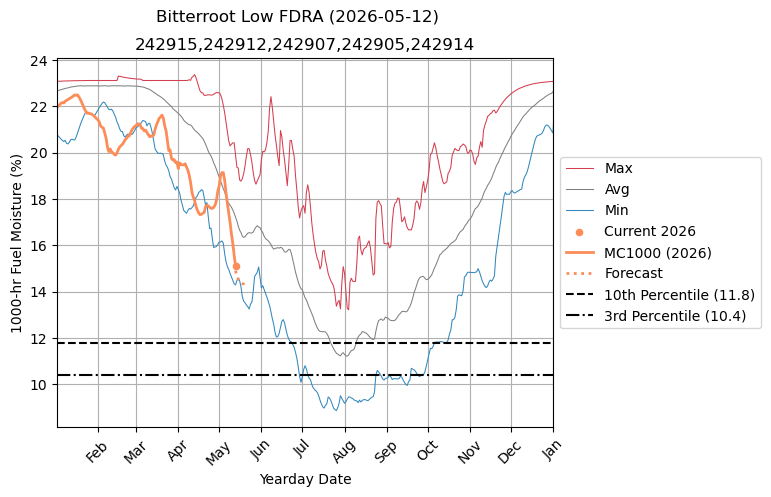

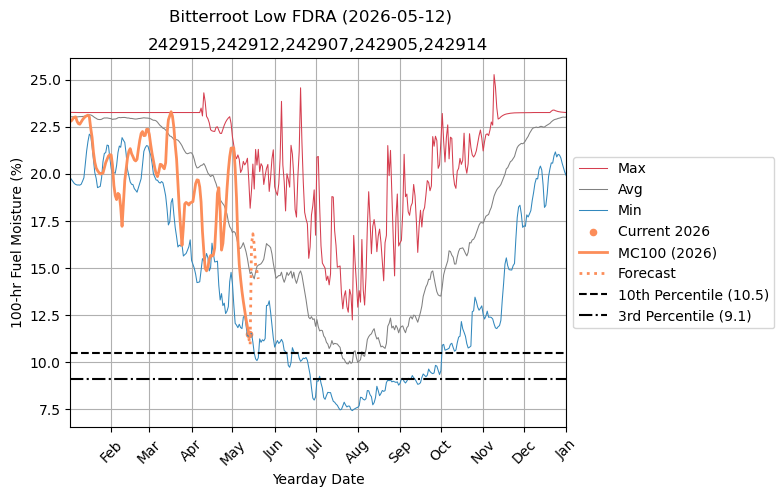

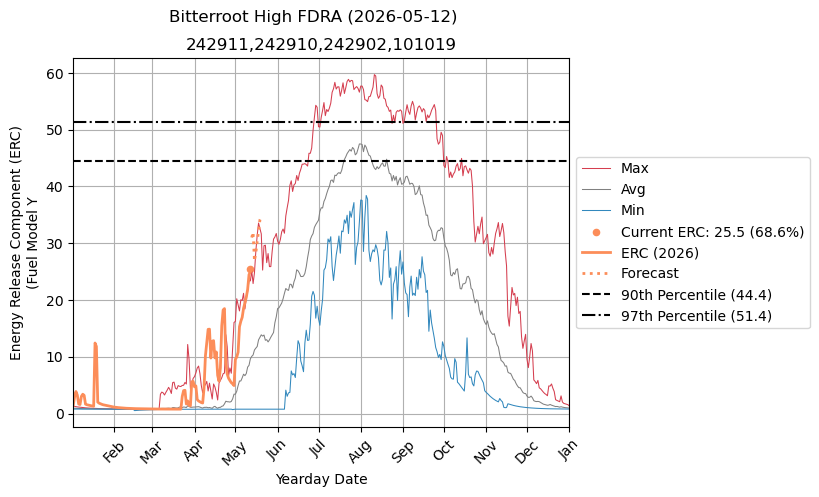

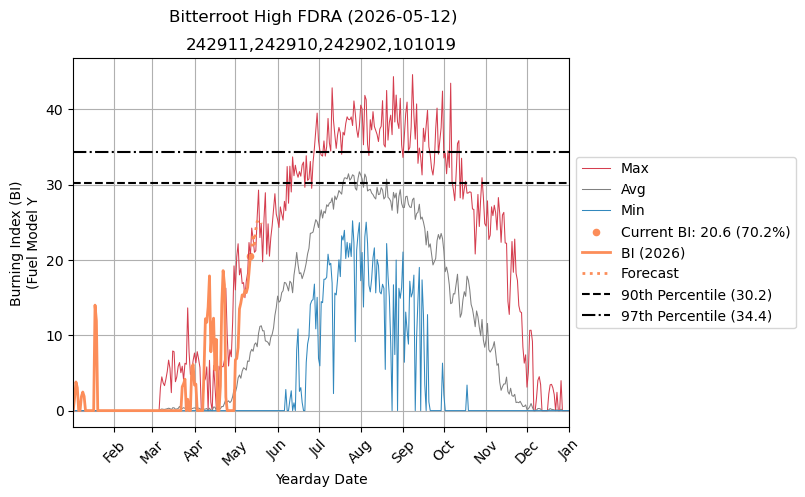

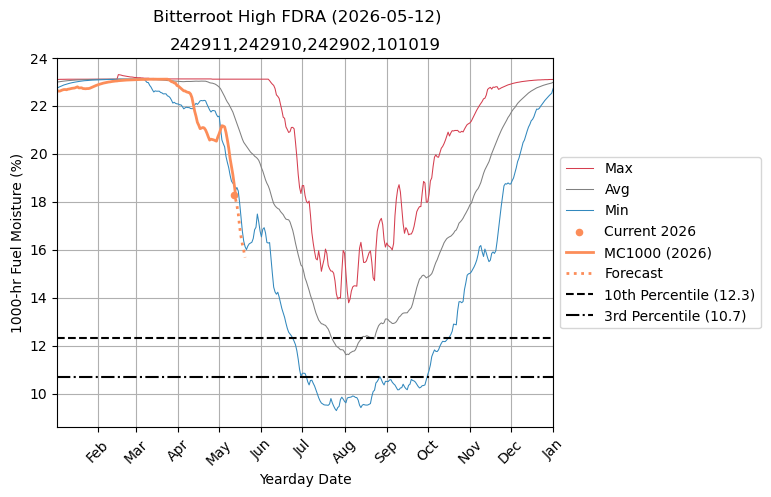

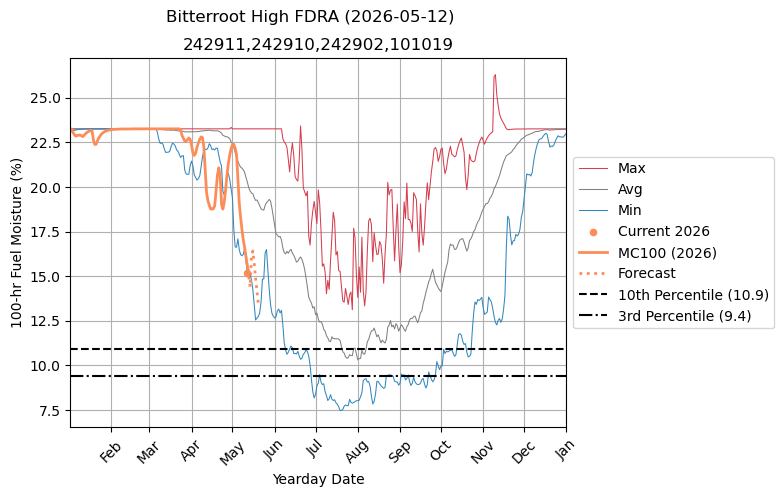

In [47]:
IterateFigures(units,variables,2026)